# [Title]

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

In [1]:
# 准备工作：导入本项目需要的库，并统一设置随机种子，保证结果可复现。
# 如果你的 notebook 环境缺少某些库，可先在单独单元运行：
# %pip install pandas numpy matplotlib seaborn scikit-learn geopandas shapely

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from urllib.parse import quote

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 设置图形风格，让后续图表在 coursework 中更清晰。
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42

# 数据统一从 GitHub 读取，便于 notebook 在干净环境中复现。
GITHUB_OWNER = "hou1020"
GITHUB_REPO = "CASA0006-coursework"
GITHUB_BRANCH = "main"
GITHUB_RAW_BASE = f"https://raw.githubusercontent.com/{GITHUB_OWNER}/{GITHUB_REPO}/{GITHUB_BRANCH}"
GITHUB_ARCHIVE_URL = f"https://github.com/{GITHUB_OWNER}/{GITHUB_REPO}/archive/refs/heads/{GITHUB_BRANCH}.zip"

def github_raw_url(path):
    return f"{GITHUB_RAW_BASE}/{quote(path, safe='/')}"

crime_url = github_raw_url("MPS Ward Level Crime (most recent 24 months).csv")
profile_url = github_raw_url("ward-profiles-excel-version.csv")
ptai_url = github_raw_url("Ward2014 AvPTAI2015.csv")
ward_shp_zip_member = (
    f"{GITHUB_REPO}-{GITHUB_BRANCH}/"
    "London-wards-2018/London-wards-2018_ESRI/London_Ward_CityMerged.shp"
)


## Research questions

[[ go back to the top ]](#Table-of-contents)

In [2]:
# 研究问题对应的机器学习任务：
# 使用 ward 的社会人口与建成环境特征，预测该 ward 是否属于高记录犯罪风险区域。
# y = 1 表示犯罪率位于全部 ward 的前 25%；y = 0 表示其余 ward。

research_question = (
    "To what extent can socio-demographic and built environment features "
    "distinguish high recorded-crime risk wards from other wards in London?"
)
print(research_question)


To what extent can socio-demographic and built environment features distinguish high recorded-crime risk wards from other wards in London?


## Data

[[ go back to the top ]](#Table-of-contents)

In [3]:
# 1. 读取数据
# 所有 CSV 均从 GitHub raw 链接读取；ward profile 文件来自 Excel 导出，包含 £ 等字符，因此使用 latin1 更稳妥。
crime_raw = pd.read_csv(crime_url)
profiles_raw = pd.read_csv(profile_url, encoding="latin1")
ptai_raw = pd.read_csv(ptai_url)

print("Crime data shape:", crime_raw.shape)
print("Ward profile shape:", profiles_raw.shape)
print("PTAI data shape:", ptai_raw.shape)

# 识别犯罪表中的月份列，例如 202403、202404 等。
month_cols = [col for col in crime_raw.columns if str(col).isdigit()]
print(f"Number of monthly crime columns: {len(month_cols)}")
print("Date range:", min(month_cols), "to", max(month_cols))

# 将每种犯罪类型、每个月份的记录汇总到 ward 层级。
# 保留 borough 名称，用于新旧 ward code 不一致时进行名称匹配。
crime_by_ward = (
    crime_raw
    .assign(Total_Crime=crime_raw[month_cols].sum(axis=1))
    .groupby(["WardCode", "WardName", "LookUp_BoroughName"], as_index=False)["Total_Crime"]
    .sum()
)

# profile 表中 City of London 有重复编码，因此先按 New code 去重。
profiles = profiles_raw.drop_duplicates(subset="New code", keep="first").copy()
ptai = ptai_raw.drop_duplicates(subset="Ward Code", keep="first").copy()

# 犯罪表使用较新的 ward code，而 ward profile 是 2014/2015 旧 ward code。
# 因此先尝试编码合并；如果匹配过少，则退回到 Borough + Ward name 的标准化名称合并。
ward_df_code = crime_by_ward.merge(
    profiles,
    left_on="WardCode",
    right_on="New code",
    how="inner",
    validate="one_to_one",
)

if len(ward_df_code) >= 100:
    ward_df = ward_df_code.copy()
    merge_strategy = "Ward code"
else:
    def normalise_name(series):
        return (
            series.astype(str)
            .str.lower()
            .str.replace("&", "and", regex=False)
            .str.replace(r"[^a-z0-9]+", " ", regex=True)
            .str.strip()
        )

    profiles["Profile_Borough"] = profiles["Ward name"].str.split(" - ", n=1).str[0]
    profiles["Profile_WardName"] = profiles["Ward name"].str.split(" - ", n=1).str[1]
    profiles["Profile_WardName"] = profiles["Profile_WardName"].fillna(profiles["Ward name"])

    crime_by_ward["borough_key"] = normalise_name(crime_by_ward["LookUp_BoroughName"])
    crime_by_ward["ward_key"] = normalise_name(crime_by_ward["WardName"])
    profiles["borough_key"] = normalise_name(profiles["Profile_Borough"])
    profiles["ward_key"] = normalise_name(profiles["Profile_WardName"])

    ward_df = crime_by_ward.merge(
        profiles,
        on=["borough_key", "ward_key"],
        how="inner",
        validate="one_to_one",
    )
    merge_strategy = "Borough + normalised ward name"

print(f"Merge strategy used: {merge_strategy}")
print(f"Matched wards: {len(ward_df)} out of {crime_by_ward['WardCode'].nunique()} crime wards")

# 加入 2015 年公共交通可达性变量。
# PTAI 使用 2014 ward code，因此与 profile 的 New code 合并，而不是与新版犯罪 WardCode 合并。
ward_df = ward_df.merge(
    ptai[["Ward Code", "AvPTAI2015", "PTAL"]],
    left_on="New code",
    right_on="Ward Code",
    how="left",
)

print("Merged ward-level data shape:", ward_df.shape)
display(ward_df[["WardCode", "WardName", "LookUp_BoroughName", "Total_Crime", "Population - 2015", "AvPTAI2015"]].head())


Crime data shape: (18669, 30)
Ward profile shape: (660, 67)
PTAI data shape: (630, 4)
Number of monthly crime columns: 25
Date range: 202403 to 202603
Merge strategy used: Borough + normalised ward name
Matched wards: 411 out of 679 crime wards
Merged ward-level data shape: (411, 78)


,WardCode,WardName,LookUp_BoroughName,Total_Crime,Population - 2015,AvPTAI2015
0,E05009318,Blackwall & Cubitt Town,Tower Hamlets,3449,23250.0,NaN
1,E05009319,Bow East,Tower Hamlets,4090,15650.0,NaN
2,E05009320,Bow West,Tower Hamlets,2860,13650.0,NaN
3,E05009326,Limehouse,Tower Hamlets,982,17100.0,NaN
4,E05009332,Shadwell,Tower Hamlets,2676,15900.0,NaN


*[Note: a table that describes the selected variables for analysis and modelling is required - see the example below.]*

| Variable                            | Type         | Description                                                             |Notes   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
| Burglary crime rate                 | Numeric      | The burglary rate of MSOAs. Used as dependent variables in regression.  |   |
| Temperature                         | Numeric      | The daytime temperature                                                 |   |
| Indicator of Inner or Outer London  | Categorical  | Whether the MSOA is in Inner London.                                    |   |
| ......  | ......  | ......                                    |   |

## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

![image.png](attachment:image.png)

In [4]:
# 2. 构建犯罪率与二分类目标变量
# 犯罪率 = 最近 24 个月左右总记录犯罪数 / 2015 常住人口 * 1000。
# 注意：由于犯罪数据与人口数据年份不完全一致，结果应解释为相对风险指标，而不是精确实时犯罪率。
analysis_df = ward_df.copy()
analysis_df["Crime_Rate"] = (analysis_df["Total_Crime"] / analysis_df["Population - 2015"]) * 1000

# 将犯罪率前 25% 的 ward 标记为高风险区。
crime_rate_threshold = analysis_df["Crime_Rate"].quantile(0.75)
analysis_df["High_Risk"] = (analysis_df["Crime_Rate"] >= crime_rate_threshold).astype(int)

print(f"75th percentile crime-rate threshold: {crime_rate_threshold:.2f} crimes per 1,000 residents")
print("Class balance:")
display(
    analysis_df["High_Risk"]
    .value_counts()
    .rename(index={0: "Low risk", 1: "High risk"})
    .to_frame("count")
    .assign(share=lambda x: x["count"] / x["count"].sum())
)

# 简单查看最高犯罪率的 ward，帮助理解目标变量是否合理。
display(
    analysis_df[["WardCode", "WardName", "Total_Crime", "Population - 2015", "Crime_Rate", "High_Risk"]]
    .sort_values("Crime_Rate", ascending=False)
    .head(10)
)


75th percentile crime-rate threshold: 209.46 crimes per 1,000 residents
Class balance:


,count,share
High_Risk,,
Low risk,308,0.749392
High risk,103,0.250608


,WardCode,WardName,Total_Crime,Population - 2015,Crime_Rate,High_Risk
291,E05013808,West End,66964,11250.0,5952.355556,1
289,E05013806,St James's,43017,12050.0,3569.875519,1
189,E05013653,Bloomsbury,14333,11700.0,1225.042735,1
195,E05013662,Holborn & Covent Garden,11896,13700.0,868.321168,1
5,E05009333,Spitalfields & Banglatown,7023,11800.0,595.169492,1
283,E05013797,Knightsbridge & Belgravia,5551,10050.0,552.338308,1
282,E05013796,Hyde Park,7416,13450.0,551.375465,1
249,E05013748,Shepherd's Bush Green,6537,12950.0,504.787645,1
197,E05013666,King's Cross,6303,12550.0,502.231076,1
221,E05013703,Finsbury Park,7184,15300.0,469.542484,1


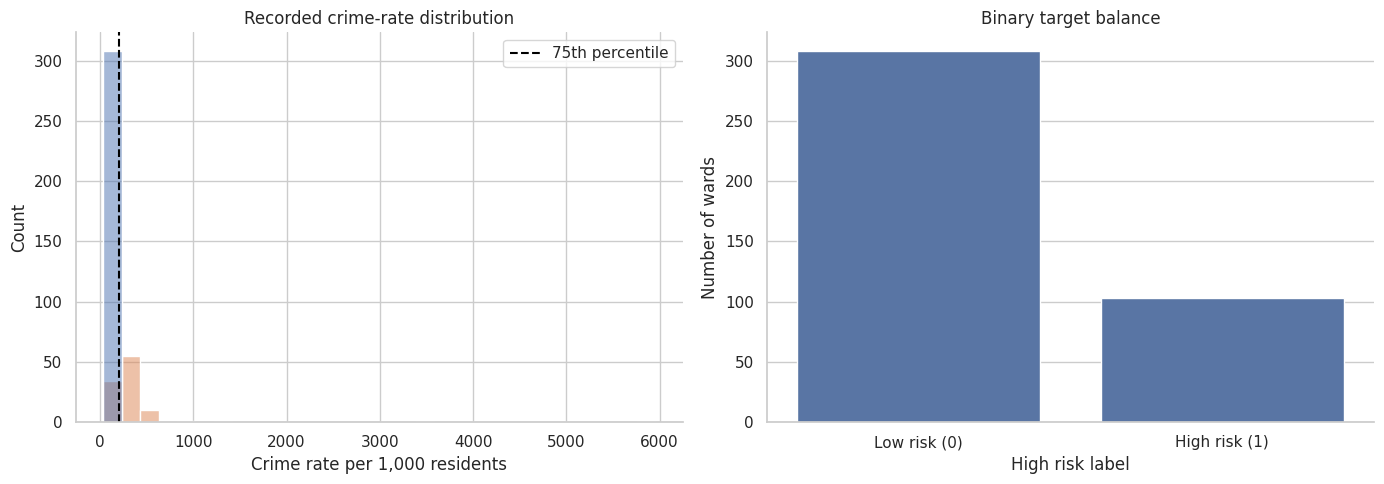

,Variable,Type,Missing values,Description / Notes
0,Population - 2015,float64,0,Socio-demographic or built environment candida...
1,Children aged 0-15 - 2015,float64,0,Socio-demographic or built environment candida...
2,Working-age (16-64) - 2015,float64,0,Socio-demographic or built environment candida...
3,Older people aged 65+ - 2015,float64,0,Socio-demographic or built environment candida...
4,% All Children aged 0-15 - 2015,float64,0,Socio-demographic or built environment candida...
...,...,...,...,...
58,Average Public Transport Accessibility score -...,float64,0,Socio-demographic or built environment candida...
59,% travel by bicycle to work - 2011,float64,0,Socio-demographic or built environment candida...
60,Turnout at Mayoral election - 2012,float64,0,Socio-demographic or built environment candida...
61,AvPTAI2015,float64,32,Socio-demographic or built environment candida...


In [5]:
# 3. 探索性分析：目标变量分布与关键变量关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=analysis_df, x="Crime_Rate", hue="High_Risk", bins=30, ax=axes[0])
axes[0].axvline(crime_rate_threshold, color="black", linestyle="--", label="75th percentile")
axes[0].set_title("Recorded crime-rate distribution")
axes[0].set_xlabel("Crime rate per 1,000 residents")
axes[0].legend()

sns.countplot(data=analysis_df, x="High_Risk", ax=axes[1])
axes[1].set_title("Binary target balance")
axes[1].set_xlabel("High risk label")
axes[1].set_xticklabels(["Low risk (0)", "High risk (1)"])
axes[1].set_ylabel("Number of wards")

plt.tight_layout()
plt.show()

# 变量字典：展示本研究使用的候选解释变量，便于 coursework Data 部分引用。
identifier_cols = {
    "WardCode", "WardName", "Ward name", "Old code", "New code", "Ward Code", "Ward Name",
    "LookUp_BoroughName", "Profile_Borough", "Profile_WardName", "borough_key", "ward_key"
}
target_and_leakage_cols = {
    # 目标变量、目标构造字段，以及 profile 中已有的犯罪/暴力/火灾变量，建模时不作为 X。
    "Total_Crime", "Crime_Rate", "High_Risk",
    "Crime rate - 2014/15", "Violence against the person rate - 2014/15",
    "Deliberate Fires per 1,000 population - 2014",
}
feature_candidates = [
    col for col in analysis_df.columns
    if col not in identifier_cols and col not in target_and_leakage_cols
]

variable_dictionary = pd.DataFrame({
    "Variable": feature_candidates,
    "Type": [str(analysis_df[col].dtype) for col in feature_candidates],
    "Missing values": [int(analysis_df[col].isna().sum()) for col in feature_candidates],
    "Description / Notes": "Socio-demographic or built environment candidate feature",
})
display(variable_dictionary)


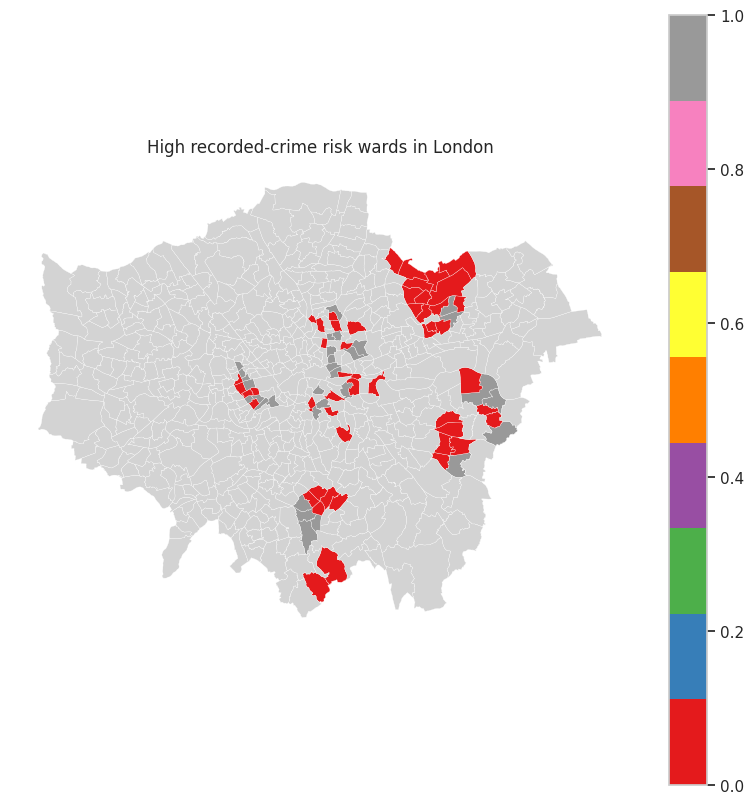

In [6]:
# 4. 空间可视化：高风险 ward 等值线地图
# 如果环境未安装 geopandas，本单元会跳过地图；模型部分不受影响。
try:
    import geopandas as gpd
    from tempfile import TemporaryDirectory
    from urllib.request import urlretrieve

    with TemporaryDirectory() as tmpdir:
        archive_path = Path(tmpdir) / "coursework-data.zip"
        urlretrieve(GITHUB_ARCHIVE_URL, archive_path)
        wards_gdf = gpd.read_file(f"zip://{archive_path}!{ward_shp_zip_member}")
    possible_code_cols = ["GSS_CODE", "WD18CD", "WD14CD", "WardCode", "New code"]
    code_col = next((col for col in possible_code_cols if col in wards_gdf.columns), None)
    if code_col is None:
        raise ValueError(f"Cannot find ward code column in shapefile. Columns: {wards_gdf.columns.tolist()}")

    map_gdf = wards_gdf.merge(
        analysis_df[["WardCode", "WardName", "Crime_Rate", "High_Risk"]],
        left_on=code_col,
        right_on="WardCode",
        how="left",
    )

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    map_gdf.plot(
        column="High_Risk",
        cmap="Set1",
        linewidth=0.2,
        edgecolor="white",
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "No data"},
        ax=ax,
    )
    ax.set_title("High recorded-crime risk wards in London")
    ax.axis("off")
    plt.show()
except Exception as err:
    print("Spatial map skipped because geopandas/shapefile reading is unavailable:", err)


In [7]:
# 5. 建模数据准备
# 删除编码、名称、目标变量和潜在泄漏变量；保留数值与少量类别特征，由 ColumnTransformer 自动处理。
X = analysis_df[feature_candidates].copy()
y = analysis_df["High_Risk"].copy()

# 删除全空列，避免预处理阶段出现无意义特征。
X = X.dropna(axis=1, how="all")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Number of features:", X.shape[1])
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features), categorical_features)

# 使用 stratify=y 保持训练集和测试集中的高/低风险比例一致。
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:")
print(y_train.value_counts(normalize=True).sort_index())

# 数值变量：中位数填补 + 标准化；类别变量：众数填补 + one-hot 编码。
# 这个结构参考 practical 中 Pipeline / ColumnTransformer 的写法，便于复现实验。
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])


Number of features: 63
Numeric features: 62
Categorical features: 1 ['PTAL']
Train shape: (328, 63)
Test shape: (83, 63)
Train class balance:
High_Risk
0    0.75
1    0.25
Name: proportion, dtype: float64


In [8]:
# 6. 基线模型：逻辑回归
# class_weight="balanced" 用于处理 1:3 左右的类别不平衡；模型系数也较容易解释。
log_reg_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

log_reg_model.fit(X_train, y_train)
log_reg_pred = log_reg_model.predict(X_test)

print("Logistic Regression classification report:")
print(classification_report(y_test, log_reg_pred, target_names=["Low risk", "High risk"]))


Logistic Regression classification report:
              precision    recall  f1-score   support

    Low risk       0.90      0.87      0.89        62
   High risk       0.65      0.71      0.68        21

    accuracy                           0.83        83
   macro avg       0.78      0.79      0.78        83
weighted avg       0.84      0.83      0.83        83



In [9]:
# 7. 进阶模型：随机森林分类器
# 随机森林可捕捉非线性关系；class_weight="balanced" 强化少数类（高风险 ward）的学习权重。
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest classification report:")
print(classification_report(y_test, rf_pred, target_names=["Low risk", "High risk"]))


Random Forest classification report:
              precision    recall  f1-score   support

    Low risk       0.88      0.94      0.91        62
   High risk       0.76      0.62      0.68        21

    accuracy                           0.86        83
   macro avg       0.82      0.78      0.80        83
weighted avg       0.85      0.86      0.85        83



## Results and discussion

[[ go back to the top ]](#Table-of-contents)

,Model,Precision_high_risk,Recall_high_risk,F1_high_risk
0,Logistic Regression,0.652174,0.714286,0.681818
1,Random Forest,0.764706,0.619048,0.684211


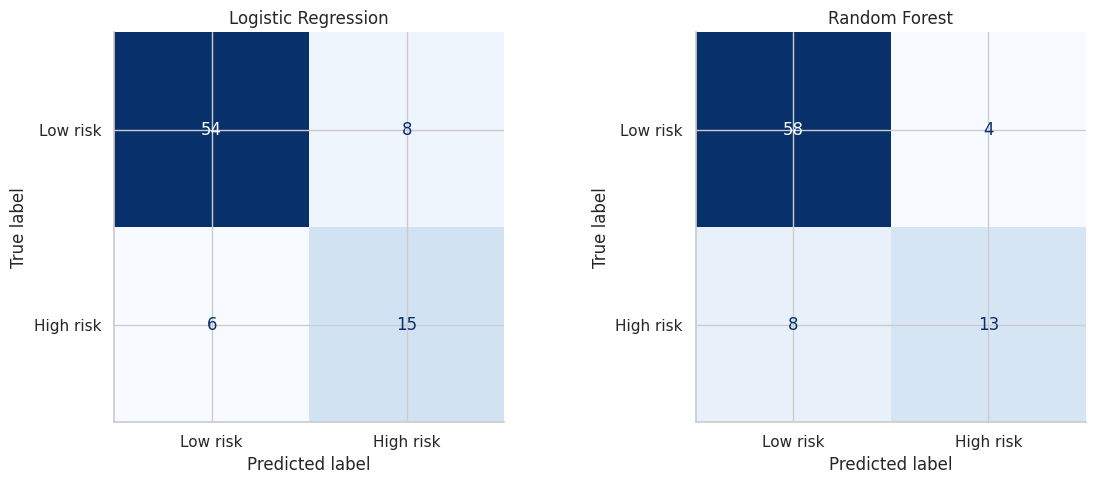

In [10]:
# 8. 模型评估与比较
# 本研究更重视 High risk 的 recall，因为漏判高风险 ward 会影响资源预防性配置。
def collect_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Precision_high_risk": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall_high_risk": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1_high_risk": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

results_df = pd.DataFrame([
    collect_metrics("Logistic Regression", y_test, log_reg_pred),
    collect_metrics("Random Forest", y_test, rf_pred),
]).sort_values("Recall_high_risk", ascending=False)

display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, pred in zip(
    axes,
    ["Logistic Regression", "Random Forest"],
    [log_reg_pred, rf_pred],
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=["Low risk", "High risk"],
        cmap="Blues",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()


,feature,coefficient,abs_coefficient
12,% Not Born in UK - 2011,-1.360780,1.360780
23,Employment rate (16-64) - 2011,-1.355181,1.355181
24,Number of jobs in area - 2013,1.311438,1.311438
25,Employment per head of resident WA population ...,1.241955,1.241955
20,Rates of ambulance call outs for alcohol relat...,1.145751,1.145751
41,Claimant rate of key out-of-work benefits (wor...,-0.934208,0.934208
63,PTAL_1b,0.885099,0.885099
49,(ID2010) % of LSOAs in worst 50% nationally - ...,0.861717,0.861717
4,% All Children aged 0-15 - 2015,-0.849477,0.849477
10,Population density (persons per sq km) - 2013,-0.834259,0.834259


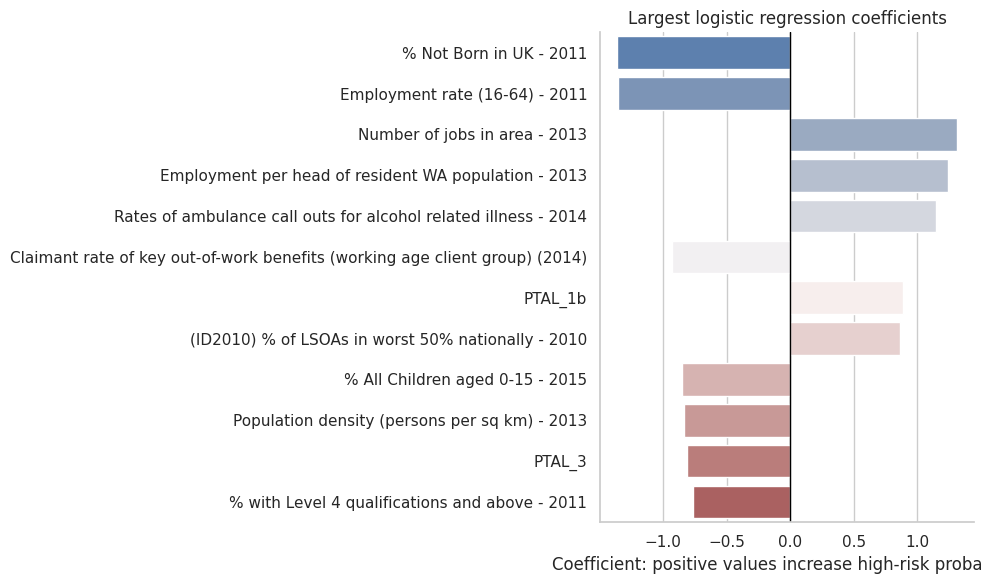

,feature,importance
19,"Rate of All Ambulance Incidents per 1,000 popu...",0.081606
20,Rates of ambulance call outs for alcohol relat...,0.062144
24,Number of jobs in area - 2013,0.059752
58,Average Public Transport Accessibility score -...,0.054342
25,Employment per head of resident WA population ...,0.038180
32,% semi-detached houses - 2011,0.035767
35,% Households Owned - 2011,0.032120
61,AvPTAI2015,0.029803
34,"% Flat, maisonette or apartment - 2011",0.027458
31,% detached houses - 2011,0.025633


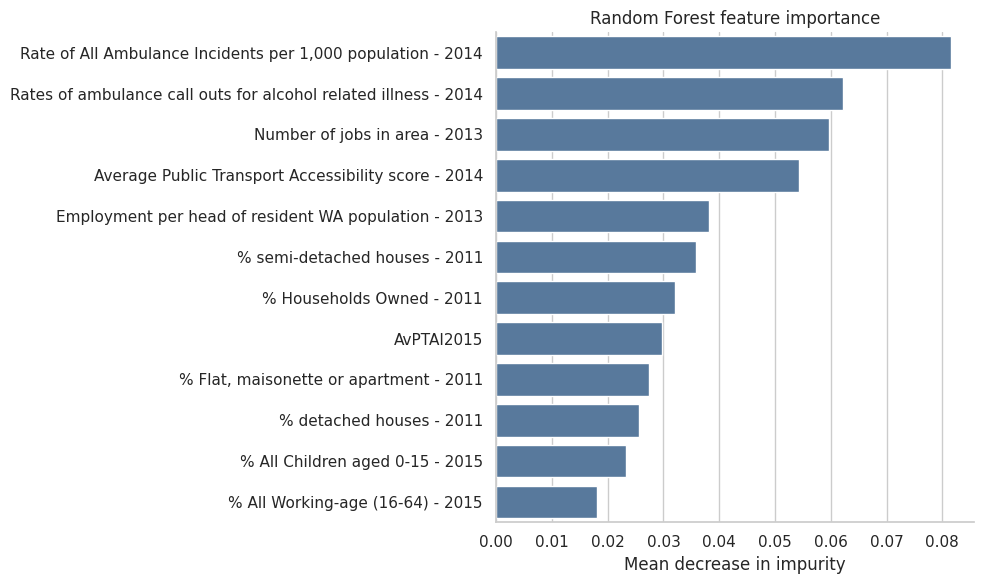

In [11]:
# 9. 模型解释：逻辑回归系数与随机森林特征重要性
# get_feature_names_out() 可以把 ColumnTransformer 后的特征名取回，方便解释模型。
feature_names = log_reg_model.named_steps["preprocess"].get_feature_names_out()
clean_feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

coef_df = pd.DataFrame({
    "feature": clean_feature_names,
    "coefficient": log_reg_model.named_steps["model"].coef_[0],
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_top = coef_df.sort_values("abs_coefficient", ascending=False).head(12)

display(coef_top)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_top, y="feature", x="coefficient", palette="vlag")
plt.axvline(0, color="black", linewidth=1)
plt.title("Largest logistic regression coefficients")
plt.xlabel("Coefficient: positive values increase high-risk probability")
plt.ylabel("")
plt.tight_layout()
plt.show()

rf_importance_df = pd.DataFrame({
    "feature": clean_feature_names,
    "importance": rf_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
rf_top = rf_importance_df.head(12)

display(rf_top)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_top, y="feature", x="importance", color="#4C78A8")
plt.title("Random Forest feature importance")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Conclusion

[[ go back to the top ]](#Table-of-contents)

In [12]:
# 10. 自动生成结果摘要，辅助撰写 Results / Conclusion 部分。
best_model_row = results_df.iloc[0]
print("Model comparison summary")
print("------------------------")
print(f"Best model by high-risk recall: {best_model_row['Model']}")
print(f"High-risk recall: {best_model_row['Recall_high_risk']:.3f}")
print(f"High-risk precision: {best_model_row['Precision_high_risk']:.3f}")
print(f"High-risk F1-score: {best_model_row['F1_high_risk']:.3f}")
print()
print("Interpretation note:")
print(
    "In this resource-allocation framing, false negatives are especially costly because "
    "they represent high-risk wards that the model fails to identify. Therefore recall "
    "for the High risk class should be discussed alongside precision and F1-score."
)


Model comparison summary
------------------------
Best model by high-risk recall: Logistic Regression
High-risk recall: 0.714
High-risk precision: 0.652
High-risk F1-score: 0.682

Interpretation note:
In this resource-allocation framing, false negatives are especially costly because they represent high-risk wards that the model fails to identify. Therefore recall for the High risk class should be discussed alongside precision and F1-score.


## References

[[ go back to the top ]](#Table-of-contents)

In [13]:
# 参考文献记录建议：
# 1. 在正文中引用 Metropolitan Police Service crime data。
# 2. 引用 London ward profile / Census-derived socio-demographic variables。
# 3. 引用 scikit-learn 文档中 LogisticRegression、RandomForestClassifier、classification_report 等方法。
# 本单元不需要运行；保留为写作提醒。
